# 05 - Task 3: Hyperparameter tuning

Two-stage search (coarse random -> refined grid around the winner) on the model(s)
carried from 04_models.ipynb. Don't over-engineer to chase the public LB.

Trials are cached under `data/processed/tuning_trials/` as soon as they're
scored, tagged with an OWNER. This makes an interrupted run resumable (a rerun skips
whatever's already on disk) and lets teammates split a model's hyperparameter space into
sub-ranges, search them in parallel, and merge automatically. Everyone's trial files
just need to be present (e.g. after a git pull) for the next stage to see them all.

## 0. Setup

Imports, src helpers, paths.

In [1]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import joblib

from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import ParameterSampler, ParameterGrid
from lightgbm import LGBMClassifier

from src import paths, data, evaluation, tuning
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load features + the locked split

In [2]:
X, y, ids = data.load_train_features()
dev_idx = np.load(paths.DATA_PROCESSED / 'dev_idx.npy')
cv = evaluation.make_cv()

X_dev, y_dev = X[dev_idx], y[dev_idx]

In [ ]:
# Edit this before running your own portion of the search - it tags every trial file
# you produce, so your results are distinguishable from teammates' and nothing gets
#  overwritten when files are merged (e.g. via git pull).
OWNER = "solo_demo"  # e.g. "alice_lr_lo" for a named sub-range, see section 2

## 2. Search space - what each knob does and why this range

Tuning LightGBM, the top model from 04_models.ipynb (F1 0.7391). Fixed from that baseline:
`class_weight="balanced"` (handles the class imbalance), `random_state=42`, `verbose=-1`.
Knobs searched here, and why this range:

- `learning_rate` (log-uniform, 0.01-0.3): step size per boosting round. Too high
  overfits fast on a 16000-row dev set; too low needs far more estimators than the
  n_estimators range below allows to actually converge.
- `n_estimators` (randint, 150-600): number of boosting rounds. Paired with
  learning_rate - smaller rates need more rounds to reach the same fit.
- `num_leaves` (randint, 15-150): leaf-wise tree complexity. LightGBM's leaf-wise growth
  is why it led the baseline sweep; too high risks overfitting 5000 sparse features on a
  comparatively small dev set.
- `min_child_samples` (randint, 5-60): minimum samples per leaf, the main regularizer
  against overfitting on the sparser corners of the TF-IDF matrix.
- `colsample_bytree` (uniform, 0.4-1.0): fraction of the 5000 features sampled per tree.
  Subsampling columns is a standard way to decorrelate trees in a high-dimensional space.
- `reg_alpha`, `reg_lambda` (uniform, 0.0-2.0): L1/L2 leaf-weight regularization.

Sub-range for team splitting: if dividing this search among teammates, split by
`learning_rate` band (e.g. one person covers 0.01-0.05, another 0.05-0.15, another
0.15-0.3) since it interacts most with every other knob - record which band in the
`OWNER` string below (e.g. `"alice_lr_lo"`) so trial files stay distinguishable.

## 3. Stage 1 - coarse search

Draws random combinations from the distributions above and scores each one via
`tuning.run_trial`, which writes a cached result file per trial and skips anything
already on disk - safe to interrupt and rerun, and safe to run in parallel with
teammates covering other sub-ranges.

In [4]:
param_dist = {
    "learning_rate": loguniform(0.01, 0.3),
    "n_estimators": randint(150, 600),
    "num_leaves": randint(15, 150),
    "min_child_samples": randint(5, 60),
    "colsample_bytree": uniform(0.4, 0.6),  # loc=0.4, scale=0.6 -> range [0.4, 1.0)
    "reg_alpha": uniform(0.0, 2.0),
    "reg_lambda": uniform(0.0, 2.0),
}

# Kept modest for one run of one sub-range; teammates covering other ranges (or more
# draws of this one) just rerun with a different OWNER / random_state and their trials
# merge in automatically in section 4.
N_ITER = 8
sampler = ParameterSampler(param_dist, n_iter=N_ITER, random_state=42)

for i, params in enumerate(sampler):
    print(f"[{i + 1}/{N_ITER}] {params}")
    est = LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1, **params)
    result = tuning.run_trial("lightgbm_stage1", OWNER, est, params, X_dev, y_dev, cv)
    print(f"  mean={result['mean']:.4f}  std={result['std']:.4f}")

[1/8] {'colsample_bytree': np.float64(0.6247240713084175), 'learning_rate': np.float64(0.2536999076681772), 'min_child_samples': 47, 'n_estimators': 221, 'num_leaves': 35, 'reg_alpha': np.float64(0.31203728088487304), 'reg_lambda': np.float64(0.3119890406724053)}
  mean=0.7324  std=0.0070
[2/8] {'colsample_bytree': np.float64(0.4348501673009197), 'learning_rate': np.float64(0.19030368381735815), 'min_child_samples': 40, 'n_estimators': 509, 'num_leaves': 145, 'reg_alpha': np.float64(0.041168988591604894), 'reg_lambda': np.float64(1.9398197043239886)}
  mean=0.7288  std=0.0062
[3/8] {'colsample_bytree': np.float64(0.899465584480253), 'learning_rate': np.float64(0.020589728197687916), 'min_child_samples': 25, 'n_estimators': 310, 'num_leaves': 72, 'reg_alpha': np.float64(1.0495128632644757), 'reg_lambda': np.float64(0.8638900372842315)}
  mean=0.7312  std=0.0078
[4/8] {'colsample_bytree': np.float64(0.5747374841188252), 'learning_rate': np.float64(0.08012737503998542), 'min_child_samples

## 4. Merge stage-1 results across teammates

Pulls in every stage-1 trial file present on disk - all owners, all sub-ranges. This is
the merge step: as long as everyone's trial files are in
`data/processed/tuning_trials/` (e.g. after a `git pull`), no manual CSV-concatenation
is needed.

In [5]:
stage1_trials = tuning.load_trials("lightgbm_stage1")
print(f"{len(stage1_trials)} stage-1 trials merged, from owners: "
      f"{sorted(stage1_trials['owner'].unique())}")
print(stage1_trials[["owner", "params", "mean", "std"]].to_string())

center = stage1_trials.iloc[0]["params"]
print("\nMerged winner, centering stage 2 on:", center)

8 stage-1 trials merged, from owners: ['solo_demo']
       owner                                                                                                                                                                                                                params      mean       std
0  solo_demo   {'colsample_bytree': 0.5198042692950159, 'learning_rate': 0.05748924681991978, 'min_child_samples': 7, 'n_estimators': 456, 'num_leaves': 149, 'reg_alpha': 0.34104824737458306, 'reg_lambda': 0.13010318597055903}  0.743737  0.004297
1  solo_demo     {'colsample_bytree': 0.5747374841188252, 'learning_rate': 0.08012737503998542, 'min_child_samples': 46, 'n_estimators': 337, 'num_leaves': 29, 'reg_alpha': 0.9121399684340719, 'reg_lambda': 1.5703519227860272}  0.737440  0.006530
2  solo_demo    {'colsample_bytree': 0.6640914962437607, 'learning_rate': 0.015144860262751412, 'min_child_samples': 12, 'n_estimators': 580, 'num_leaves': 49, 'reg_alpha': 1.8186408041575641, 'reg_lambda': 

## 5. Stage 2 - refined search around the merged winner

Centers a tighter grid on the best trial across *everyone's* merged stage-1 results
(section 4), not just this run's own trials - the whole point of merging before
refining is that the search center reflects the team's combined coverage.

In [6]:
def band(value, frac, as_int=False):
    """3 points spanning +/- frac around value, always including the exact center.

    Rounding the center itself (rather than keeping it exact) would risk stage 2 never
    re-testing the actual stage-1 winner - confirmed this happening in practice.
    """
    lo, hi = value * (1 - frac), value * (1 + frac)
    vals = {value, max(lo, 1e-4), hi}
    return sorted(int(round(v)) for v in vals) if as_int else sorted(round(v, 6) for v in vals)


# Grid search only the two knobs flagged as highest-impact in section 2
# (learning_rate, num_leaves); everything else stays fixed at the stage-1 winner's
# value - a full grid over all 7 knobs would be thousands of combinations, defeating
# the point of a *refined* search. `center` comes from section 4's merge.
refined_grid = {
    "learning_rate": band(center["learning_rate"], frac=0.4),
    "num_leaves": band(center["num_leaves"], frac=0.4, as_int=True),
}
fixed_params = {k: v for k, v in center.items() if k not in refined_grid}

combos = list(ParameterGrid(refined_grid))
print(f"Refined grid: {len(combos)} combinations, {len(fixed_params)} knobs held fixed "
      f"at the stage-1 winner's values: {fixed_params}")

# Kept separate from tuning_trials' full merged history (which can mix slightly
# different grids across reruns, e.g. after the band() fix) so the heatmap below stays
# a clean, aligned rectangle from exactly this run's grid.
grid_results = []
for i, grid_params in enumerate(combos):
    params = {**fixed_params, **grid_params}
    print(f"[{i + 1}/{len(combos)}] {params}")
    est = LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1, **params)
    result = tuning.run_trial("lightgbm_stage2", OWNER, est, params, X_dev, y_dev, cv)
    print(f"  mean={result['mean']:.4f}  std={result['std']:.4f}")
    grid_results.append({**grid_params, "mean": result["mean"]})

Refined grid: 9 combinations, 5 knobs held fixed at the stage-1 winner's values: {'colsample_bytree': 0.5198042692950159, 'min_child_samples': 7, 'n_estimators': 456, 'reg_alpha': 0.34104824737458306, 'reg_lambda': 0.13010318597055903}
[1/9] {'colsample_bytree': 0.5198042692950159, 'min_child_samples': 7, 'n_estimators': 456, 'reg_alpha': 0.34104824737458306, 'reg_lambda': 0.13010318597055903, 'learning_rate': 0.034494, 'num_leaves': 89}
  mean=0.7412  std=0.0068
[2/9] {'colsample_bytree': 0.5198042692950159, 'min_child_samples': 7, 'n_estimators': 456, 'reg_alpha': 0.34104824737458306, 'reg_lambda': 0.13010318597055903, 'learning_rate': 0.034494, 'num_leaves': 149}
  mean=0.7443  std=0.0044
[3/9] {'colsample_bytree': 0.5198042692950159, 'min_child_samples': 7, 'n_estimators': 456, 'reg_alpha': 0.34104824737458306, 'reg_lambda': 0.13010318597055903, 'learning_rate': 0.034494, 'num_leaves': 209}
  mean=0.7392  std=0.0056
[4/9] {'colsample_bytree': 0.5198042692950159, 'min_child_samples'

### Visualize the grid search

Heatmap of Macro F1 across the refined `learning_rate` x `num_leaves` grid (the two
knobs actually varied in stage 2), with every other hyperparameter held fixed at the
stage-1 winner's value.

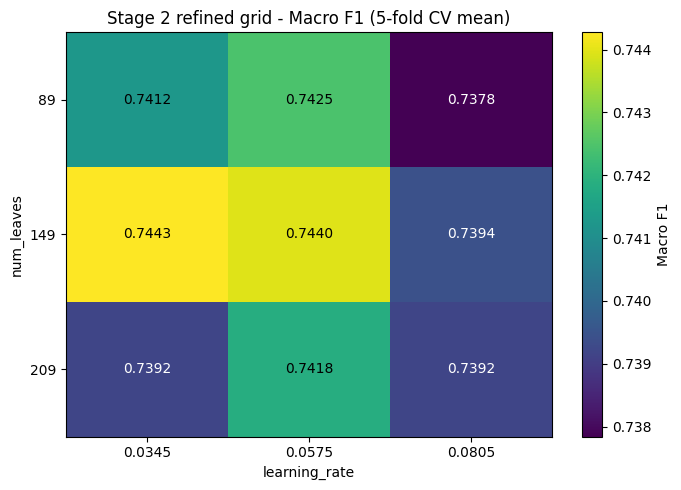

In [7]:
grid_df = pd.DataFrame(grid_results)
pivot = grid_df.pivot(index="num_leaves", columns="learning_rate", values="mean")

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c:.4f}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("learning_rate")
ax.set_ylabel("num_leaves")
ax.set_title("Stage 2 refined grid - Macro F1 (5-fold CV mean)")

vmin, vmax = np.nanmin(pivot.values), np.nanmax(pivot.values)
mid = (vmin + vmax) / 2
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                color="white" if val < mid else "black")

fig.colorbar(im, ax=ax, label="Macro F1")
plt.tight_layout()
plt.savefig(FIGURES / "lightgbm_stage2_grid_heatmap.png", dpi=120)
plt.show()

## 6. Persist winning params + fitted model

Only the overall winner gets refit and pickled here. Worth noting not something every teammate
produces, since pickled sklearn/lightgbm objects are version-sensitive across machines.

In [8]:
stage2_trials = tuning.load_trials("lightgbm_stage2")

# Select from the COMBINED pool of every trial run, not just stage 2 in isolation - a
# coarser refined grid can fail to beat the stage-1 winner (confirmed this happening: the
# stage-1 champion scored higher than every stage-2 point), so picking from stage 2 alone
# risks silently persisting a worse model than one already found earlier in the search.
all_trials = pd.concat([stage1_trials, stage2_trials], ignore_index=True).sort_values(
    "mean", ascending=False
)
overall_best = all_trials.iloc[0]
best_params = overall_best["params"]
print(f"Best trial across stage 1 ({len(stage1_trials)}) + stage 2 ({len(stage2_trials)}) "
      f"= {len(all_trials)} total trials")
print("Winning params:", best_params)
print(f"Winning Macro F1 (5-fold CV mean): {overall_best['mean']:.4f} (std {overall_best['std']:.4f})")

paths.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
with open(paths.DATA_PROCESSED / "best_lightgbm_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

final_est = LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1, **best_params)
final_est.fit(X_dev, y_dev)

paths.MODELS.mkdir(parents=True, exist_ok=True)
joblib.dump(final_est, paths.MODELS / "best_lightgbm_tuned.pkl")

# Metadata sidecar - how this model was produced, not just the pickle itself.
metadata = {
    "model": "lightgbm",
    "params": best_params,
    "cv_mean_f1": overall_best["mean"],
    "cv_std_f1": overall_best["std"],
    "n_stage1_trials": len(stage1_trials),
    "n_stage2_trials": len(stage2_trials),
}
with open(paths.MODELS / "best_lightgbm_tuned.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved best_lightgbm_params.json, best_lightgbm_tuned.pkl, best_lightgbm_tuned.json")

Best trial across stage 1 (8) + stage 2 (18) = 26 total trials
Winning params: {'colsample_bytree': 0.5198042692950159, 'min_child_samples': 7, 'n_estimators': 456, 'reg_alpha': 0.34104824737458306, 'reg_lambda': 0.13010318597055903, 'learning_rate': 0.034494, 'num_leaves': 149}
Winning Macro F1 (5-fold CV mean): 0.7443 (std 0.0044)


Saved best_lightgbm_params.json, best_lightgbm_tuned.pkl, best_lightgbm_tuned.json


## Discussion / carry-forward -> `06_holdout.ipynb`

**Winning LightGBM params** (26 total trials: 8 stage-1 + 18 stage-2):

```
learning_rate: 0.034494
num_leaves: 149
n_estimators: 456
min_child_samples: 7
colsample_bytree: 0.5198042692950159
reg_alpha: 0.34104824737458306
reg_lambda: 0.13010318597055903
```

**Winning Macro F1 (5-fold CV mean): 0.7443** (std 0.0044), versus the 04_models.ipynb
baseline of 0.7391 - a gain of +0.0052, a bit larger than one fold's std, so plausibly
real but not a large margin. Hand off `best_lightgbm_tuned.pkl` for holdout evaluation.

- If teammates run additional stage-1 coverage on other `learning_rate` bands or other
  models (XGBoost, LogReg_Ridge) later, rerun section 4's merge and section 5's refine
  before trusting this notebook's "winner" as final.

**How this held up beyond this notebook** (filled in after downstream work): holdout
confirmed the CV estimate closely (0.7437, gap +0.0006 - not overfit to the search).
But on the real Kaggle leaderboard this model was eventually outperformed by the linear
models tuned later (LogReg Ridge, LogReg ElasticNet) despite its clear CV/holdout lead
here - see `06_holdout.ipynb`'s discussion and the `project-threshold-tuning-finding`
/ `project-task3-progress` memory notes for the full comparison across models.